In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
data = load_breast_cancer()

x = pd.DataFrame(
    data.data,
    columns=data.feature_names)
y = pd.Series((data.target == 0).astype(int),name="malignant")
print(y.value_counts())
print("feature matrix shape",x.shape)
print("target shape",y.shape)
print("class names",data.target_names)






malignant
0    357
1    212
Name: count, dtype: int64
feature matrix shape (569, 30)
target shape (569,)
class names ['malignant' 'benign']


In [4]:
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class":data.target_names,
    "count":class_counts.values,
    "Probability": class_counts.values / len(y)
})
print(class_distribution)

       Class  count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


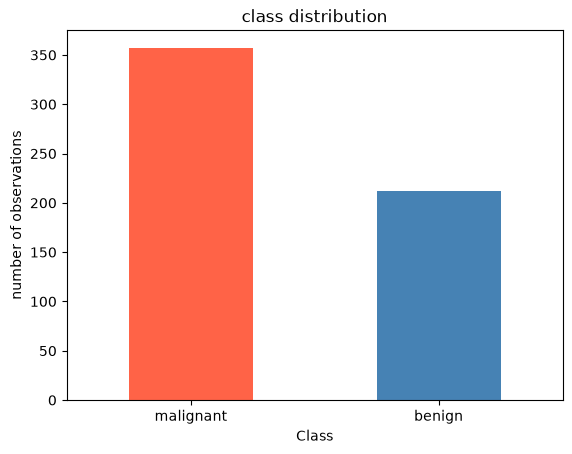

In [10]:
class_distribution.plot(
    x="Class",  # <-- Make sure this matches your exact column name!
    y="count",
    kind="bar",
    legend=False,
    color=["tomato", "steelblue"]
)

plt.ylabel("number of observations")
plt.title("class distribution")
plt.xticks(rotation=0)
plt.show()


In [12]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,test_size=0.20,
    random_state=42,
    stratify=y

)
print("training size",len(y_train))
print("testing size",len(y_test))
print("\ntraining proportions")
print(y_train.value_counts(normalize=True).sort_index())
print("\ntesting proportions")
print(y_test.value_counts(normalize=True).sort_index())


training size 455
testing size 114

training proportions
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

testing proportions
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [13]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
probabilities= model.predict_proba(x_test)
print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]
